# Multi-Dataset Benchmark Analysis

Multi-dataset benchmark comparison on the shared-success subset.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from utils import (
    benchmark_overview,
    constraint_quality_summary,
    constraint_quality_tables,
    build_validity_curve_df,
    curve_auc_table,
    curve_endpoint_table,
    evaluate_empirical_robustness_curves,
    load_result_set,
    load_tabular_benchmark_models,
    method_order,
    method_palette,
    metric_table,
    plot_heatmap,
    plot_validity_distance_curves,
    proximity_summary,
    select_methods,
    setup_notebook_style,
    shared_success_retention_summary,
    shared_success_subset,
    style_method_table,
    validity_summary,
)

setup_notebook_style()


In [2]:
RESULT_FILES = {
    'adult': Path('../results/benchmark_adult_meeting.parquet'),
    'compas': Path('../results/benchmark_compas_meeting.parquet'),
    'german_credit': Path('../results/benchmark_german_credit_meeting.parquet'),
    'heloc': Path('../results/benchmark_heloc_meeting.parquet'),
    'give_me_some_credit': Path('../results/benchmark_give_me_some_credit_meeting.parquet'),
    'lending_club': Path('../results/benchmark_lending_club_meeting.parquet'),
}
SELECTED_METHODS = None
BENCHMARK_CONFIG = Path('../configs/benchmarks/benchmark_meeting_all.yaml')
ROBUSTNESS_DEVICE = 'cpu'
ROBUSTNESS_SAMPLES = 64
ROBUSTNESS_SEED = 42
ROBUSTNESS_EPSILONS = {
    'l1': [0.05, 0.10, 0.25, 0.50, 1.00],
    'l2': [0.01, 0.05, 0.10, 0.25, 0.50],
    'linf': [0.01, 0.05, 0.10, 0.20],
}


In [3]:
df, status_df = load_result_set(RESULT_FILES)
if SELECTED_METHODS:
    df = select_methods(df, SELECTED_METHODS)

retention = shared_success_retention_summary(
    df,
    by=('dataset', 'query_idx'),
    group_cols=('dataset',),
    method_col='method_label',
)
df = shared_success_subset(df, by=('dataset', 'query_idx'), method_col='method_label')

order = method_order(df)
palette = method_palette(order)
datasets_here = [name for name in RESULT_FILES if name in df['dataset'].unique()]

display(status_df)
display(retention.style.format({'retention_pct': '{:.1f}%'}))
display(benchmark_overview(df))
print(f'Shared-success rows: {len(df)}')
print(f'Method order: {order}')


,dataset,requested_path,resolved_path,available
0,adult,../results/benchmark_adult_meeting.parquet,/home/gabrielepintus/Documents/github/Preimage...,True
1,compas,../results/benchmark_compas_meeting.parquet,/home/gabrielepintus/Documents/github/Preimage...,True
2,german_credit,../results/benchmark_german_credit_meeting.par...,/home/gabrielepintus/Documents/github/Preimage...,True
3,heloc,../results/benchmark_heloc_meeting.parquet,/home/gabrielepintus/Documents/github/Preimage...,True
4,give_me_some_credit,../results/benchmark_give_me_some_credit_meeti...,/home/gabrielepintus/Documents/github/Preimage...,True
5,lending_club,../results/benchmark_lending_club_meeting.parquet,/home/gabrielepintus/Documents/github/Preimage...,True


,n_total_tasks,n_shared_tasks,retention_pct
dataset,,,
adult,50,19,38.0%
compas,50,44,88.0%
german_credit,50,0,0.0%
give_me_some_credit,50,22,44.0%
heloc,50,36,72.0%
lending_club,50,44,88.0%


,n_rows,n_methods,n_queries,n_datasets,n_success
0,825,5,163,5,825


Shared-success rows: 825
Method order: ['CertCF', 'DiCE', 'FACE', 'Growing Spheres', 'Nearest Neighbor']


,n_total,n_valid,validity_pct
method_label,,,
CertCF,165,165,100.0%
DiCE,165,165,100.0%
FACE,165,165,100.0%
Growing Spheres,165,165,100.0%
Nearest Neighbor,165,165,100.0%


dataset,adult,compas,give_me_some_credit,heloc,lending_club
method_label,,,,,
CertCF,100.0%,100.0%,100.0%,100.0%,100.0%
DiCE,100.0%,100.0%,100.0%,100.0%,100.0%
FACE,100.0%,100.0%,100.0%,100.0%,100.0%
Growing Spheres,100.0%,100.0%,100.0%,100.0%,100.0%
Nearest Neighbor,100.0%,100.0%,100.0%,100.0%,100.0%


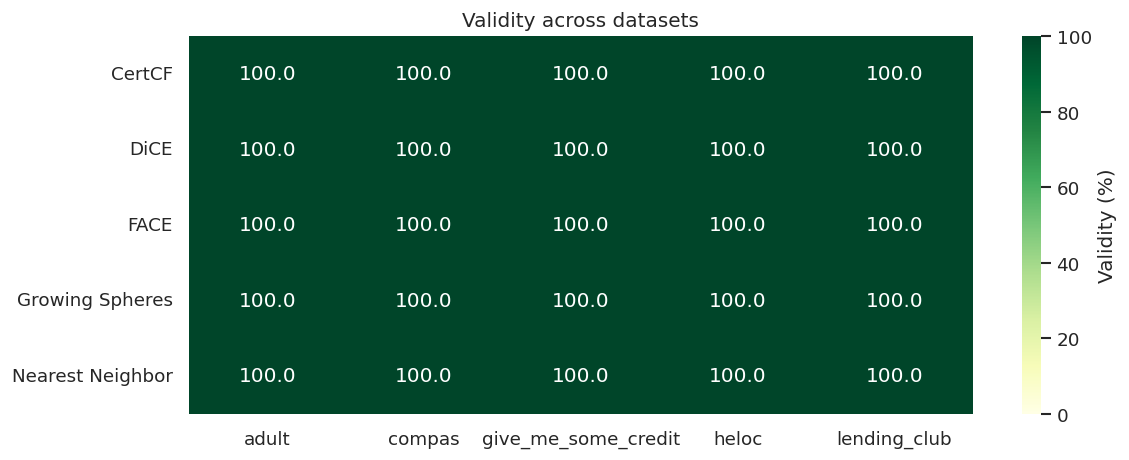

In [4]:
validity = validity_summary(df, order=order)
display(style_method_table(validity, fmt={'validity_pct': '{:.1f}%'}, maximize=['validity_pct', 'n_valid']))
validity_table = metric_table(df, 'success', index='method_label', columns='dataset', scale=100.0, order=order)
display(style_method_table(validity_table, fmt='{:.1f}%', maximize=list(validity_table.columns), gradient_cmap='YlGn'))
plot_heatmap(validity_table, title='Validity across datasets', cmap='YlGn', fmt='.1f', cbar_label='Validity (%)', vmin=0, vmax=100)
plt.show()


dataset,adult,compas,give_me_some_credit,heloc,lending_club
method_label,,,,,
CertCF,0.438,0.693,0.659,0.569,0.626
DiCE,0.684,0.541,0.347,0.511,0.440
FACE,0.315,0.666,0.461,0.495,0.555
Growing Spheres,0.876,0.812,0.767,0.803,0.839
Nearest Neighbor,0.411,0.770,0.645,0.600,0.694


dataset,adult,compas,give_me_some_credit,heloc,lending_club
method_label,,,,,
CertCF,0.620,0.750,0.711,0.436,0.599
DiCE,0.881,0.693,0.689,0.729,0.586
FACE,0.510,0.723,0.513,0.356,0.499
Growing Spheres,0.938,0.853,0.806,0.825,0.869
Nearest Neighbor,0.626,0.867,0.726,0.553,0.731


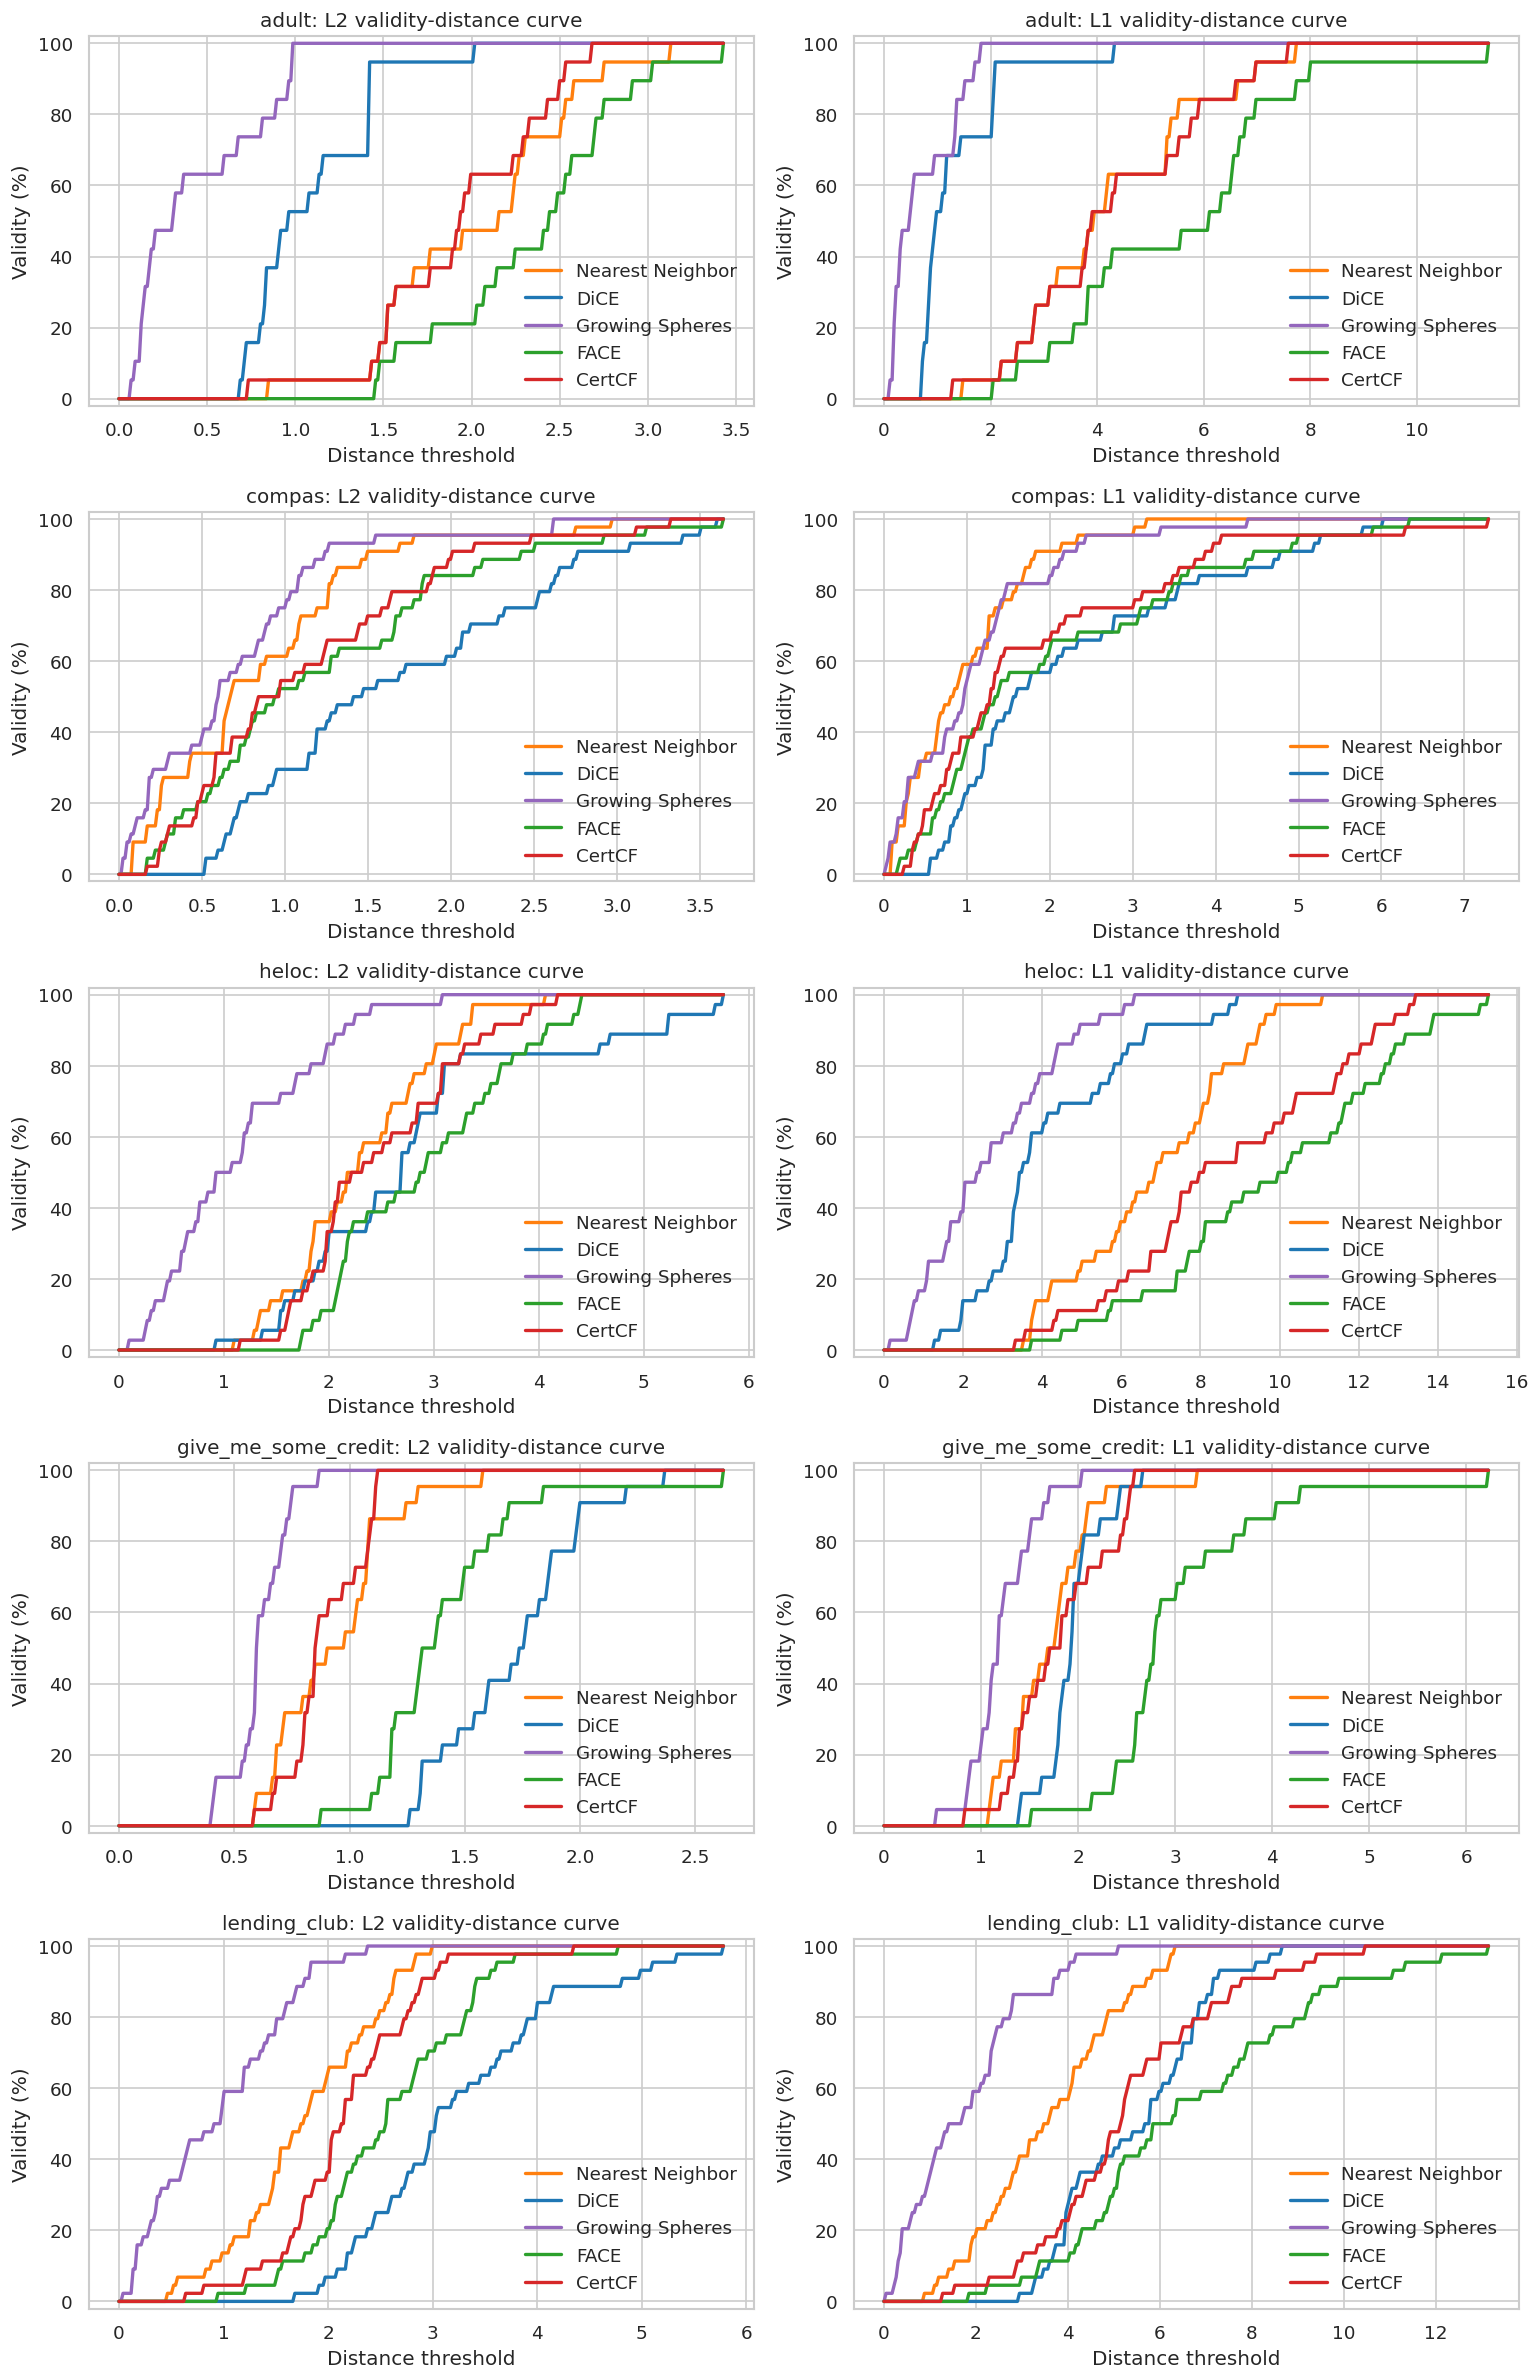

In [5]:
curve_l2 = build_validity_curve_df(
    df,
    metric='l2_distance',
    group_cols=('dataset', 'method_label'),
    eps_group_cols=('dataset',),
)
curve_l1 = build_validity_curve_df(
    df,
    metric='l1_distance',
    group_cols=('dataset', 'method_label'),
    eps_group_cols=('dataset',),
)

curve_auc_l2 = curve_auc_table(curve_l2, index='method_label', columns='dataset', order=order)
curve_auc_l1 = curve_auc_table(curve_l1, index='method_label', columns='dataset', order=order)
display(style_method_table(curve_auc_l2, fmt='{:.3f}', maximize=list(curve_auc_l2.columns)))
display(style_method_table(curve_auc_l1, fmt='{:.3f}', maximize=list(curve_auc_l1.columns)))

fig, axes = plt.subplots(len(datasets_here), 2, figsize=(13, 4.0 * max(1, len(datasets_here))), squeeze=False)
for row, dataset_name in enumerate(datasets_here):
    plot_validity_distance_curves(
        curve_l2[curve_l2['dataset'] == dataset_name],
        palette=palette,
        title=f'{dataset_name}: L2 validity-distance curve',
        ax=axes[row, 0],
    )
    plot_validity_distance_curves(
        curve_l1[curve_l1['dataset'] == dataset_name],
        palette=palette,
        title=f'{dataset_name}: L1 validity-distance curve',
        ax=axes[row, 1],
    )
fig.tight_layout()
plt.show()


,mean_l2,median_l2,mean_l1,median_l1,mean_mad_l1,mean_sparsity,mean_redundancy,n_rows
method_label,,,,,,,,
CertCF,1.756,1.775,4.510,3.863,6.306,0.444,0.614,165.000
DiCE,2.276,2.058,3.365,3.100,1.108,0.408,0.771,165.000
FACE,2.104,2.070,5.487,4.857,2.940,0.435,0.627,165.000
Growing Spheres,0.808,0.651,1.575,1.207,5.578,0.241,0.099,165.000
Nearest Neighbor,1.554,1.472,3.410,2.802,1.976,0.342,0.564,165.000


dataset,adult,compas,give_me_some_credit,heloc,lending_club
method_label,,,,,
CertCF,1.927,1.118,0.893,2.480,2.160
DiCE,1.085,1.671,1.712,2.817,3.235
FACE,2.349,1.216,1.413,2.911,2.570
Growing Spheres,0.425,0.684,0.611,1.134,0.928
Nearest Neighbor,2.019,0.837,0.931,2.302,1.771


dataset,adult,compas,give_me_some_credit,heloc,lending_club
method_label,,,,,
CertCF,0.058,0.332,44.326,1.023,0.292
DiCE,0.013,0.252,5.743,0.334,0.753
FACE,0.076,0.343,18.599,1.200,0.366
Growing Spheres,0.012,0.234,40.347,0.359,0.210
Nearest Neighbor,0.059,0.272,12.528,0.771,0.219


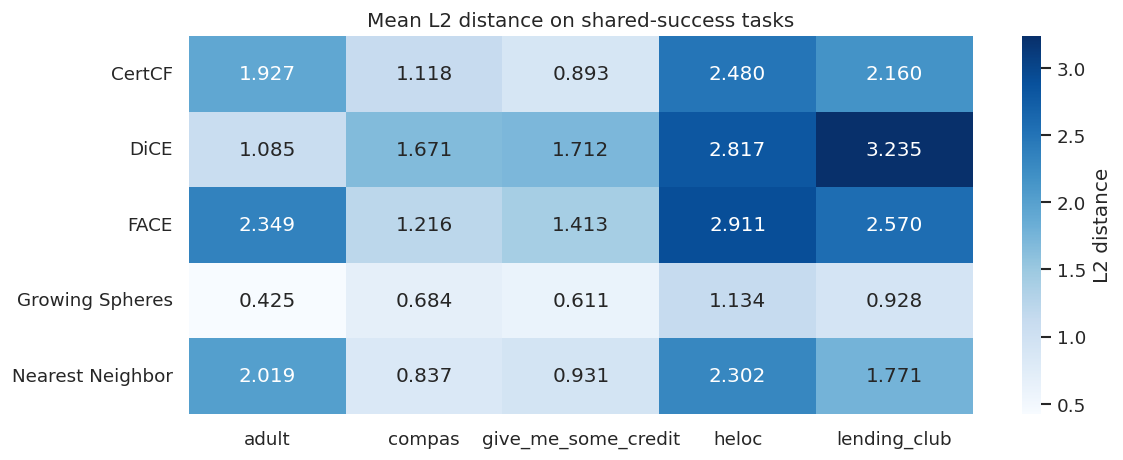

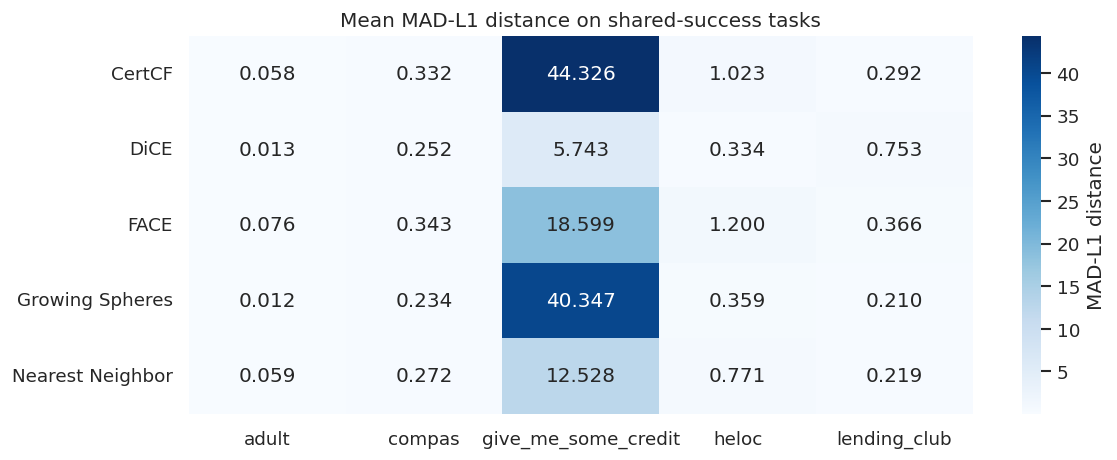

In [6]:
proximity = proximity_summary(df, order=order, success_only_rows=False)
display(style_method_table(proximity, fmt='{:.3f}', minimize=['mean_l2', 'median_l2', 'mean_l1', 'median_l1', 'mean_mad_l1', 'mean_sparsity', 'mean_redundancy']))
l2_table = metric_table(df, 'l2_distance', index='method_label', columns='dataset', order=order, success_only_rows=False)
mad_table = metric_table(df, 'mad_l1_distance', index='method_label', columns='dataset', order=order, success_only_rows=False)
display(style_method_table(l2_table, fmt='{:.3f}', minimize=list(l2_table.columns), gradient_cmap='Blues'))
display(style_method_table(mad_table, fmt='{:.3f}', minimize=list(mad_table.columns), gradient_cmap='Blues'))
plot_heatmap(l2_table, title='Mean L2 distance on shared-success tasks', cmap='Blues', fmt='.3f', cbar_label='L2 distance')
plt.show()
plot_heatmap(mad_table, title='Mean MAD-L1 distance on shared-success tasks', cmap='Blues', fmt='.3f', cbar_label='MAD-L1 distance')
plt.show()


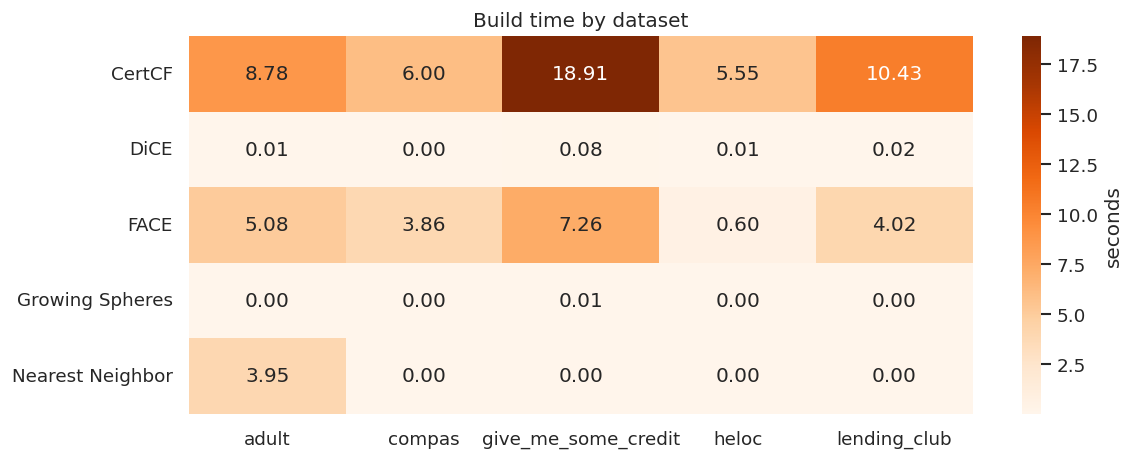

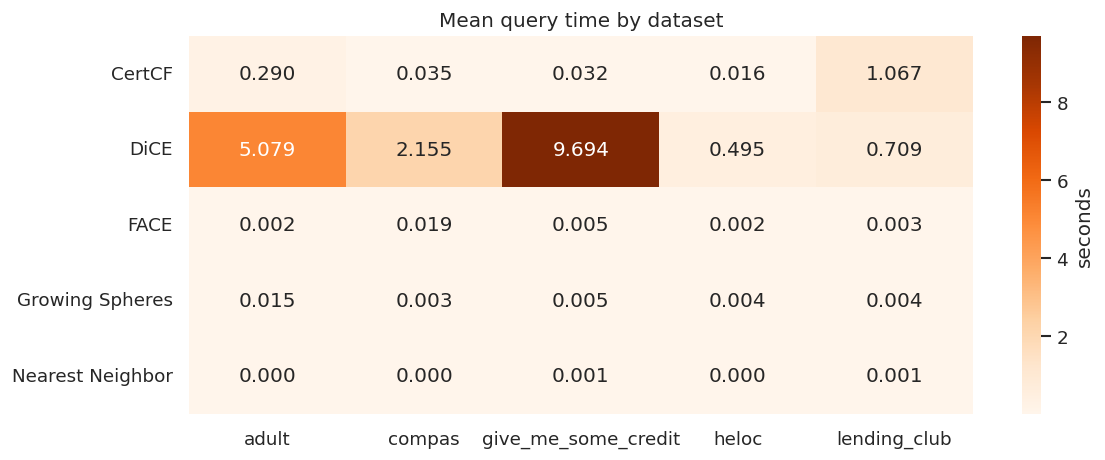

In [7]:
build_time_table = metric_table(df, 'build_time_s', index='method_label', columns='dataset', agg='first', order=order)
mean_query_time_table = metric_table(df, 'runtime_s', index='method_label', columns='dataset', agg='mean', order=order)
plot_heatmap(build_time_table, title='Build time by dataset', cmap='Oranges', fmt='.2f', cbar_label='seconds')
plt.show()
plot_heatmap(mean_query_time_table, title='Mean query time by dataset', cmap='Oranges', fmt='.3f', cbar_label='seconds')
plt.show()


[INFO] Retrying checkpoint load with hidden_dims inferred from checkpoint: [128, 32]
L1 empirical robustness


dataset,adult,compas,give_me_some_credit,heloc,lending_club
method_label,,,,,
CertCF,5.3%,2.3%,0.0%,52.8%,15.9%
DiCE,47.4%,6.8%,100.0%,100.0%,100.0%
FACE,15.8%,0.0%,13.6%,27.8%,18.2%
Growing Spheres,0.0%,0.0%,0.0%,0.0%,0.0%
Nearest Neighbor,10.5%,0.0%,0.0%,63.9%,9.1%


dataset,adult,compas,give_me_some_credit,heloc,lending_club
method_label,,,,,
CertCF,0.407,0.195,0.153,0.569,0.330
DiCE,0.749,0.470,0.950,0.950,0.950
FACE,0.499,0.191,0.402,0.500,0.457
Growing Spheres,0.009,0.012,0.068,0.242,0.076
Nearest Neighbor,0.405,0.095,0.242,0.777,0.359


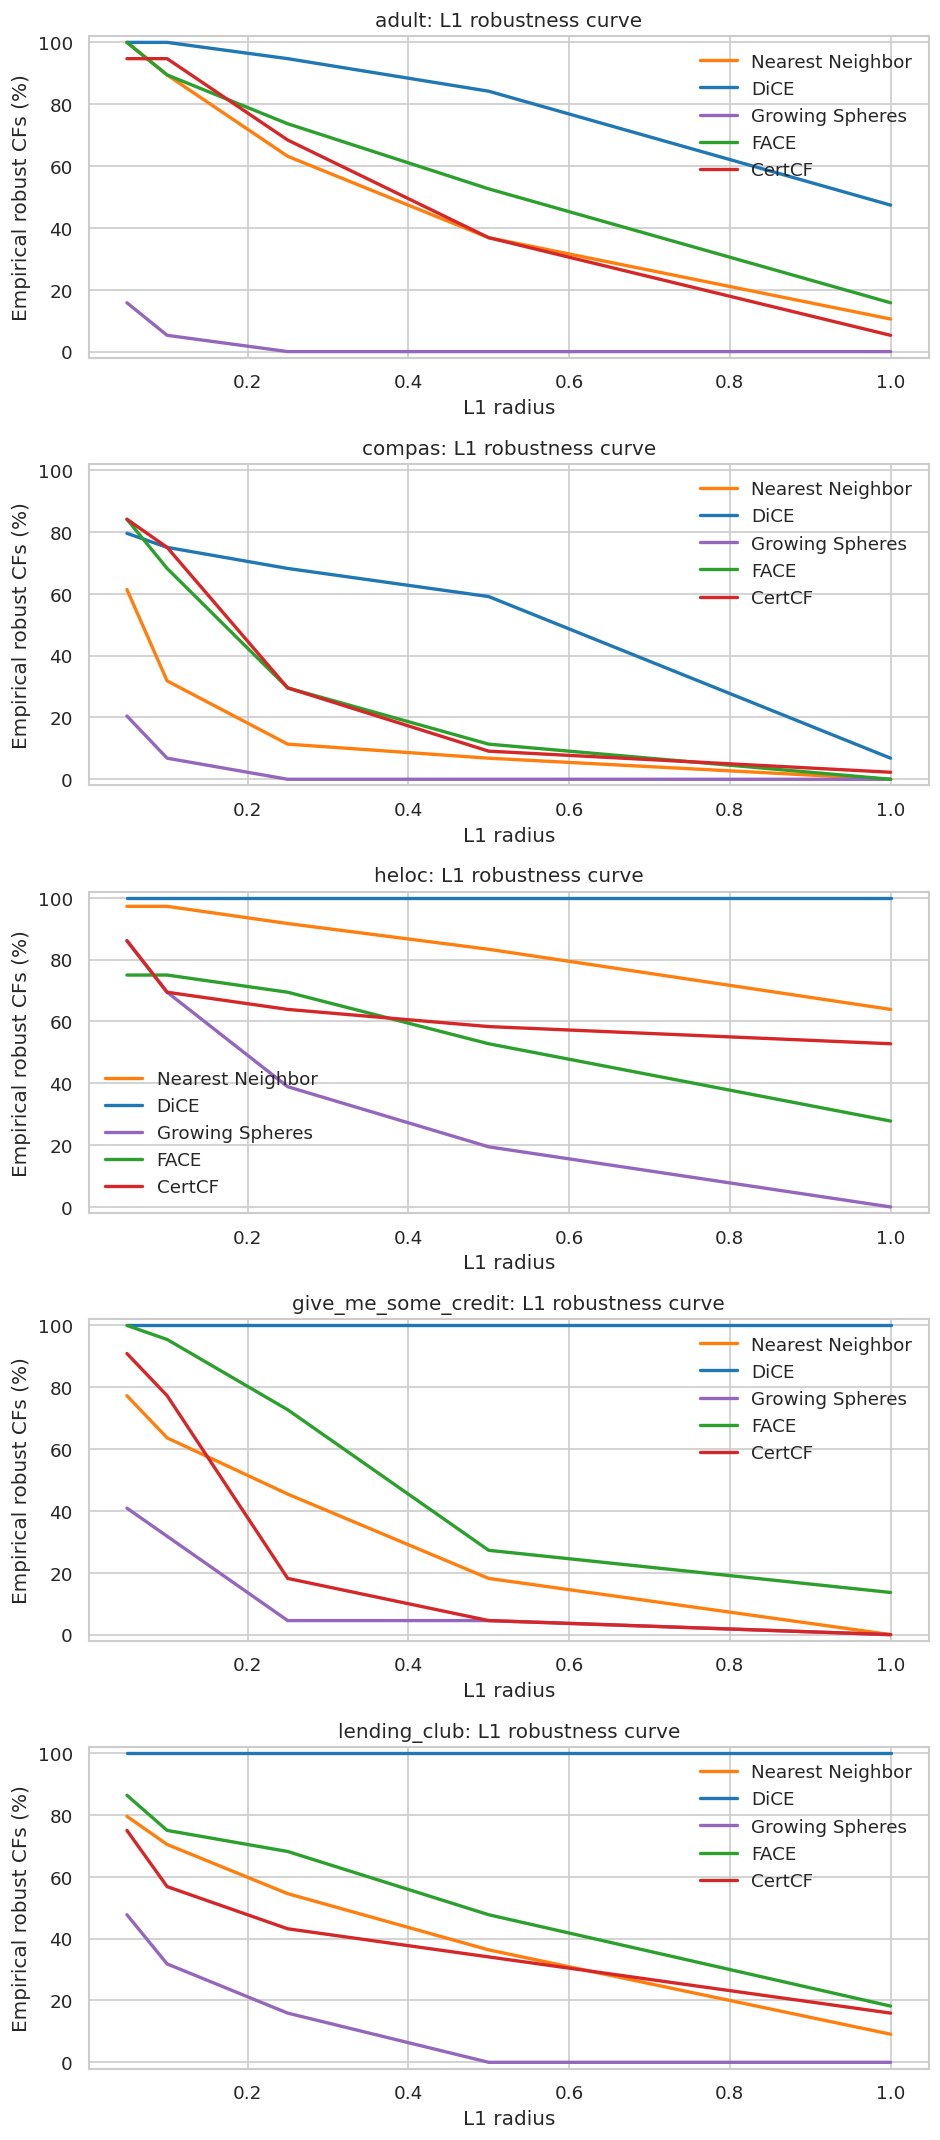

L2 empirical robustness


dataset,adult,compas,give_me_some_credit,heloc,lending_club
method_label,,,,,
CertCF,5.3%,2.3%,0.0%,38.9%,18.2%
DiCE,57.9%,20.5%,100.0%,100.0%,100.0%
FACE,21.1%,0.0%,13.6%,19.4%,22.7%
Growing Spheres,0.0%,0.0%,0.0%,0.0%,0.0%
Nearest Neighbor,26.3%,2.3%,0.0%,33.3%,11.4%


dataset,adult,compas,give_me_some_credit,heloc,lending_club
method_label,,,,,
CertCF,0.454,0.302,0.152,0.528,0.366
DiCE,0.833,0.574,0.980,0.980,0.980
FACE,0.541,0.252,0.415,0.419,0.508
Growing Spheres,0.017,0.041,0.073,0.166,0.113
Nearest Neighbor,0.512,0.166,0.242,0.642,0.412


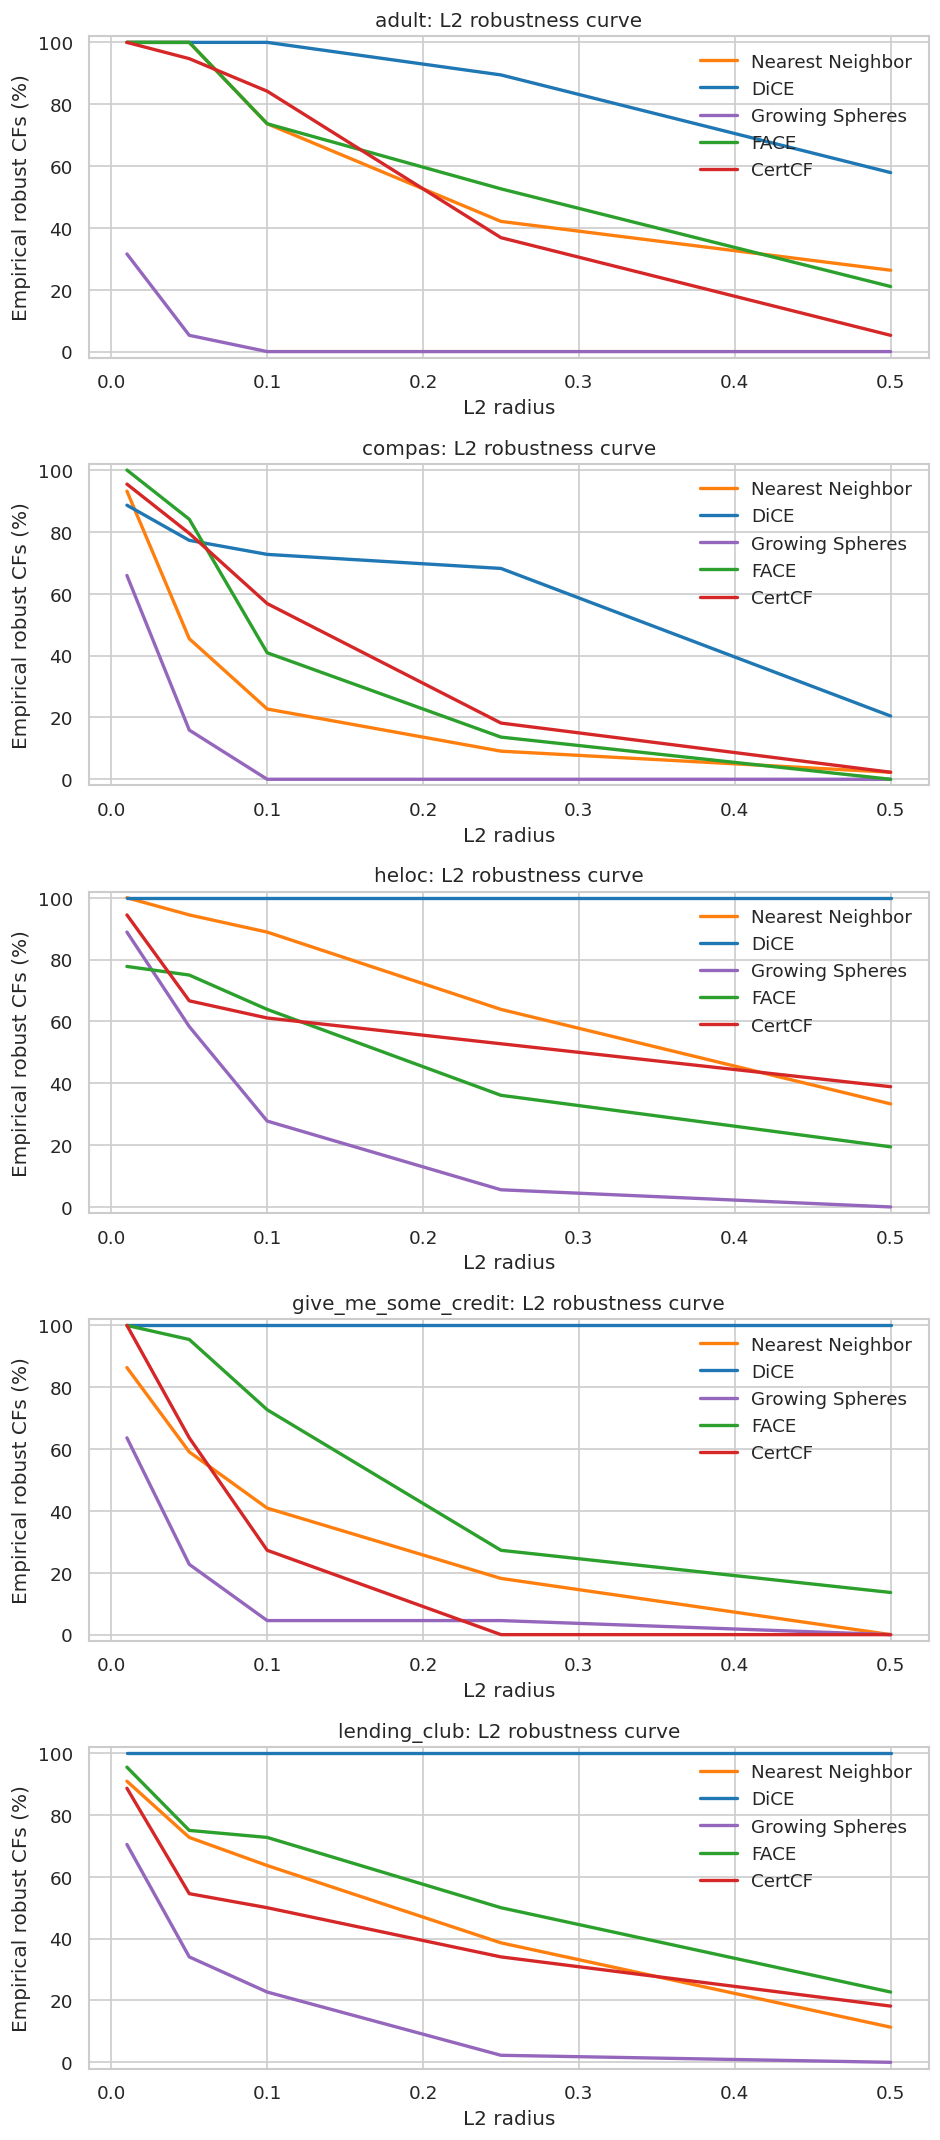

LINF empirical robustness


dataset,adult,compas,give_me_some_credit,heloc,lending_club
method_label,,,,,
CertCF,31.6%,11.4%,0.0%,30.6%,31.8%
DiCE,84.2%,61.4%,100.0%,100.0%,100.0%
FACE,42.1%,13.6%,9.1%,13.9%,31.8%
Growing Spheres,0.0%,0.0%,0.0%,0.0%,0.0%
Nearest Neighbor,36.8%,6.8%,0.0%,30.6%,22.7%


dataset,adult,compas,give_me_some_credit,heloc,lending_club
method_label,,,,,
CertCF,0.617,0.437,0.165,0.458,0.438
DiCE,0.891,0.673,0.950,0.950,0.950
FACE,0.628,0.377,0.389,0.328,0.590
Growing Spheres,0.026,0.059,0.068,0.101,0.161
Nearest Neighbor,0.607,0.230,0.255,0.590,0.457


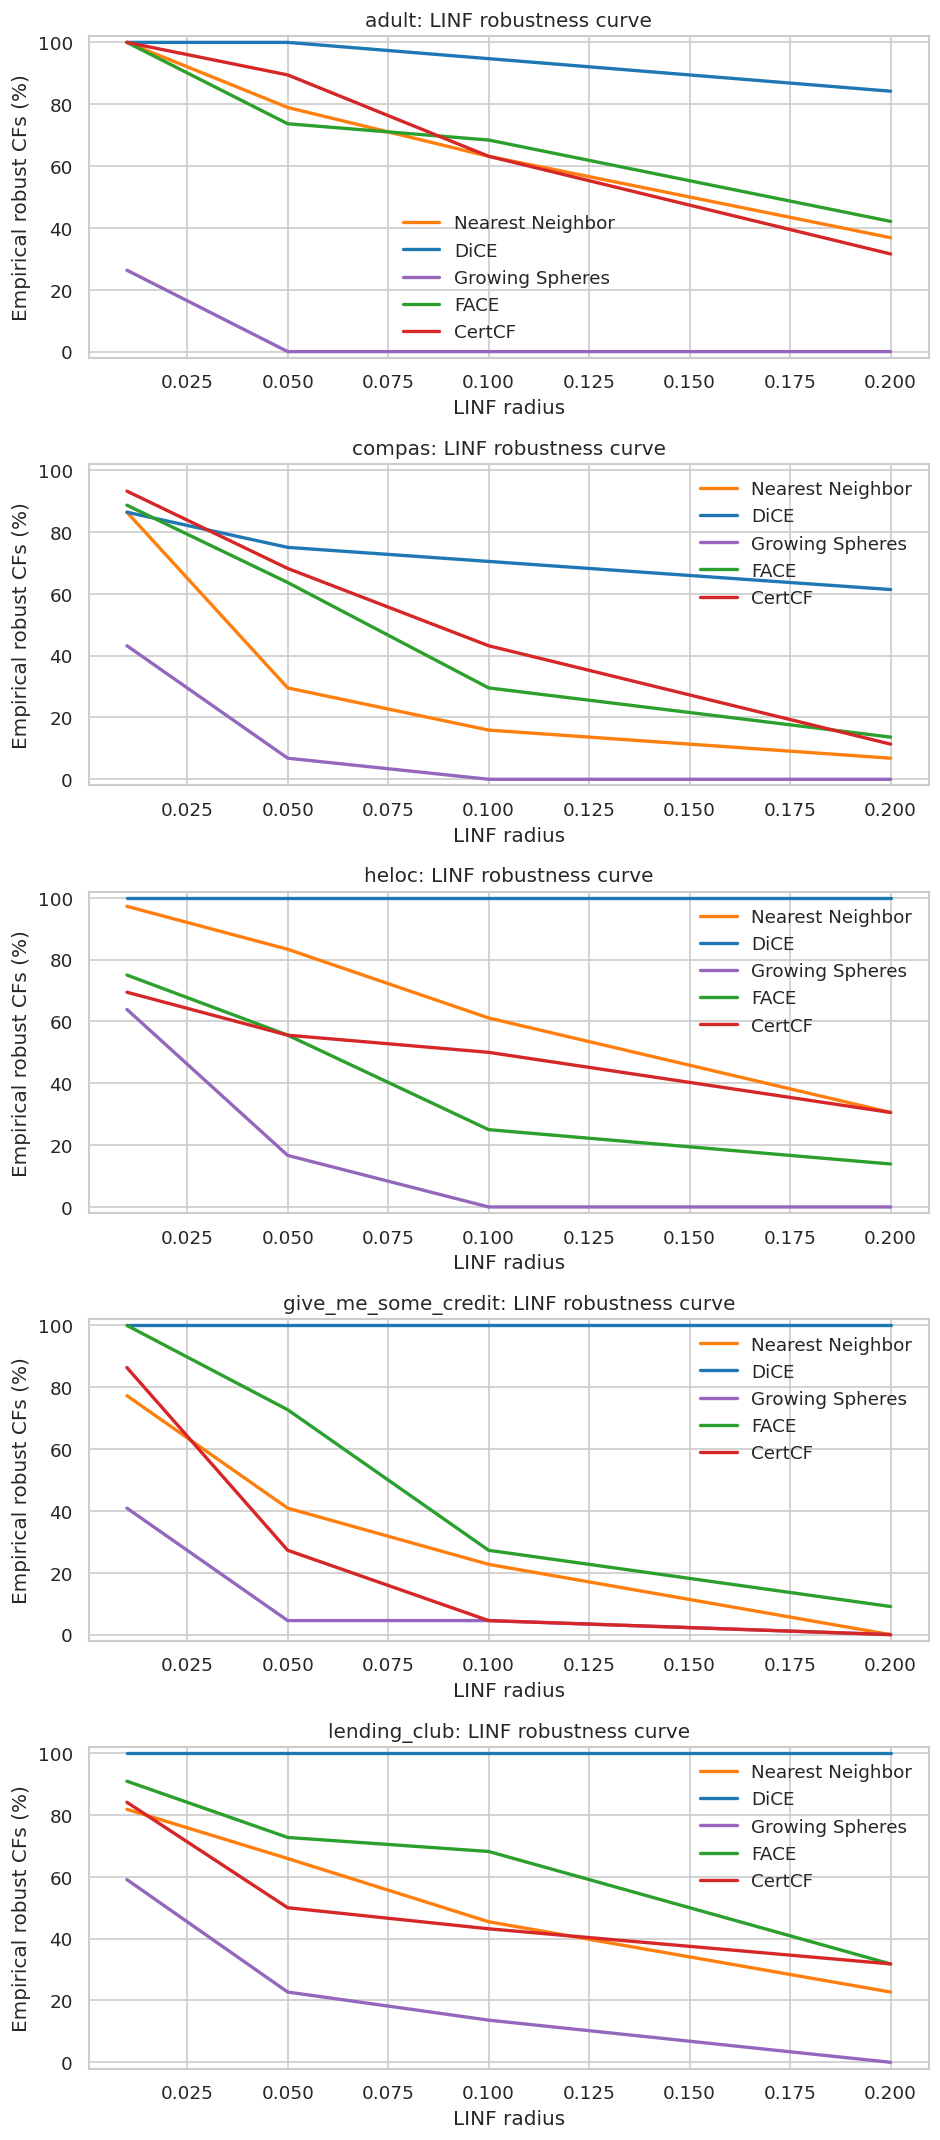

In [8]:
robust_models = load_tabular_benchmark_models(
    BENCHMARK_CONFIG,
    datasets=datasets_here,
    device=ROBUSTNESS_DEVICE,
)
robustness_curves = evaluate_empirical_robustness_curves(
    df,
    models_by_dataset=robust_models,
    eps_by_norm=ROBUSTNESS_EPSILONS,
    n_samples=ROBUSTNESS_SAMPLES,
    seed=ROBUSTNESS_SEED,
)

for norm_name in ('l1', 'l2', 'linf'):
    norm_df = robustness_curves[robustness_curves['norm'] == norm_name].copy()
    if norm_df.empty:
        continue

    print(f'{norm_name.upper()} empirical robustness')
    robust_endpoint = curve_endpoint_table(norm_df, order=order)
    robust_auc = curve_auc_table(norm_df, index='method_label', columns='dataset', order=order)
    display(style_method_table(robust_endpoint, fmt='{:.1f}%', maximize=list(robust_endpoint.columns), gradient_cmap='Greens'))
    display(style_method_table(robust_auc, fmt='{:.3f}', maximize=list(robust_auc.columns), gradient_cmap='Greens'))

    fig, axes = plt.subplots(len(datasets_here), 1, figsize=(8, 3.6 * max(1, len(datasets_here))), squeeze=False)
    for row, dataset_name in enumerate(datasets_here):
        plot_validity_distance_curves(
            norm_df[norm_df['dataset'] == dataset_name],
            palette=palette,
            title=f'{dataset_name}: {norm_name.upper()} robustness curve',
            xlabel=f'{norm_name.upper()} radius',
            ylabel='Empirical robust CFs (%)',
            ax=axes[row, 0],
        )
    fig.tight_layout()
    plt.show()


## Constraint-Quality Diagnostics

These OHE/categorical checks are **diagnostic only** for debugging and ablations. They are computed on the shared-success subset and are not part of the headline fairness comparison.


Skipping numerical-only datasets: give_me_some_credit, heloc


/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/notebooks/utils/constraints.py:152: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(rows, ignore_index=True)
/home/gabrielepintus/Documents/github/PreimageCounterfactualSampling/notebooks/utils/constraints.py:152: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(rows, ignore_index=True)


,n_rows,ohe_valid_pct,mean_invalid_block_pct,mean_ohe_snap_l1,immutable_valid_pct,mean_immutable_change_pct,mean_immutable_l1
method_label,,,,,,,
CertCF,107,100.0%,0.0%,0.000,98.4%,1.6%,0.032
DiCE,107,58.9%,41.1%,1.305,100.0%,0.0%,0.000
FACE,107,100.0%,0.0%,0.000,92.1%,7.9%,0.159
Growing Spheres,107,67.3%,16.4%,0.139,100.0%,0.0%,0.000
Nearest Neighbor,107,100.0%,0.0%,0.000,100.0%,0.0%,0.000


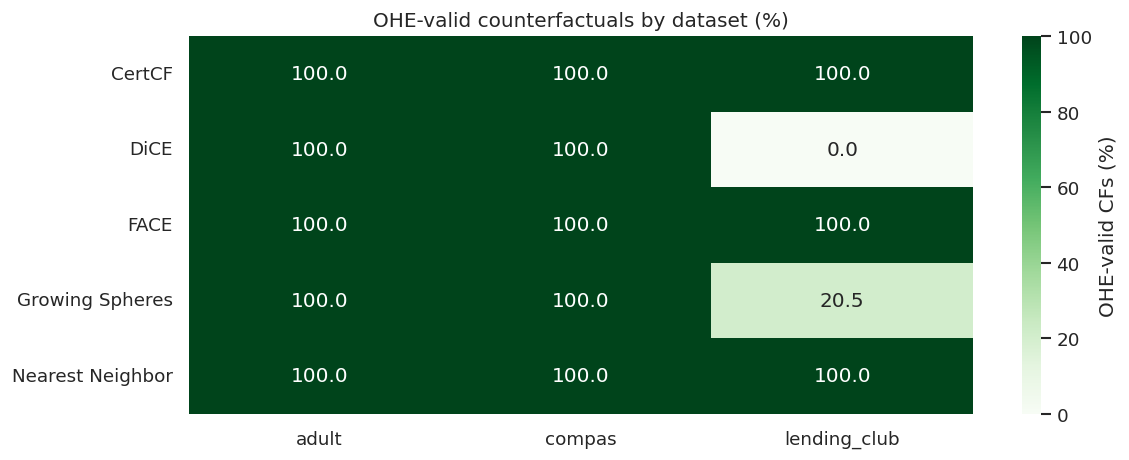

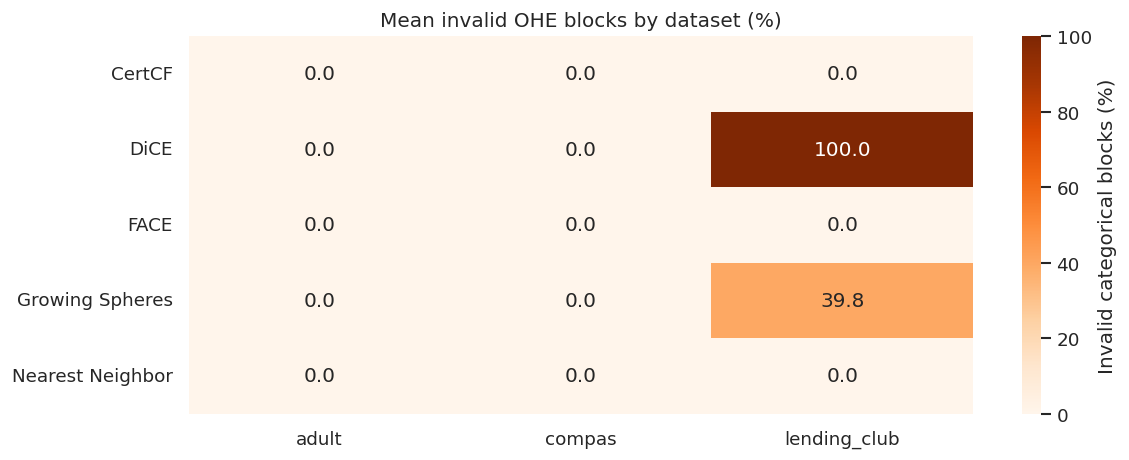

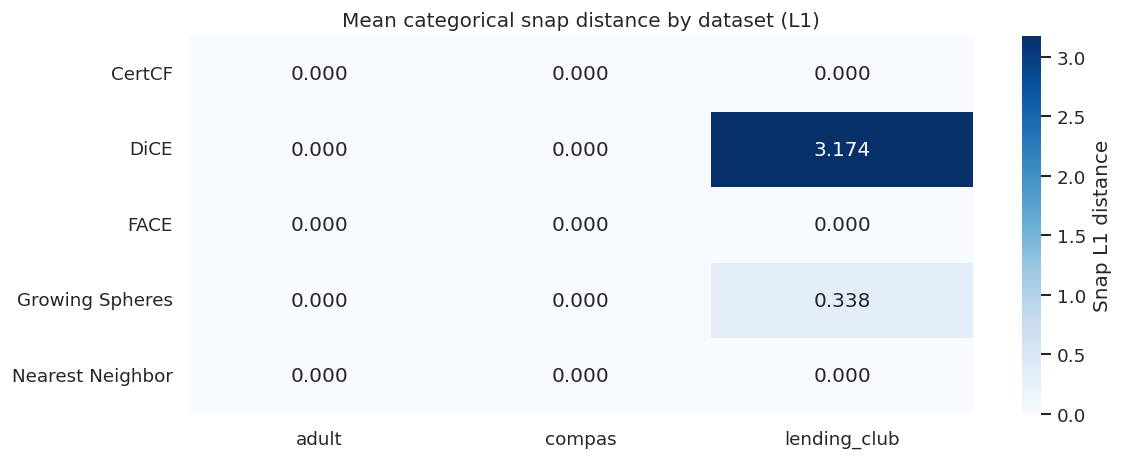

Immutable-feature diagnostics available for: adult, compas


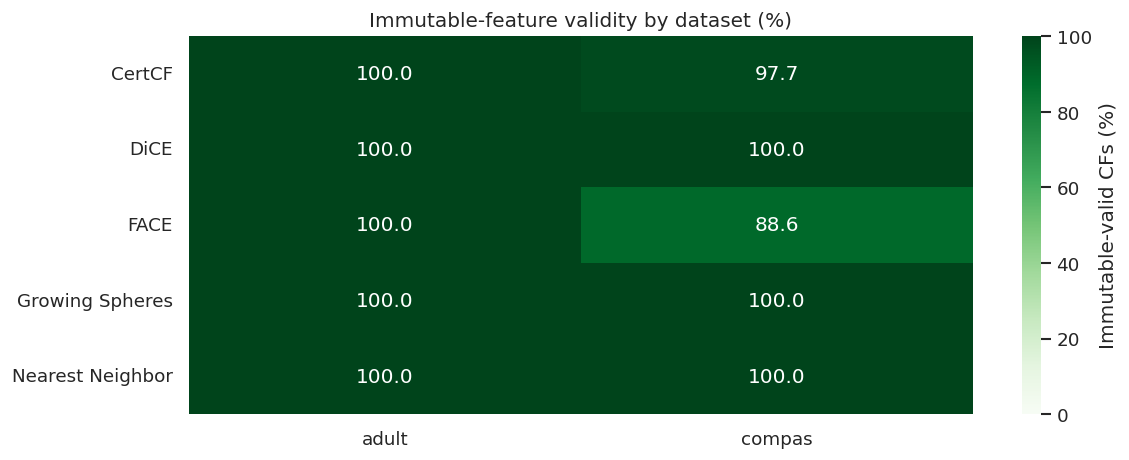

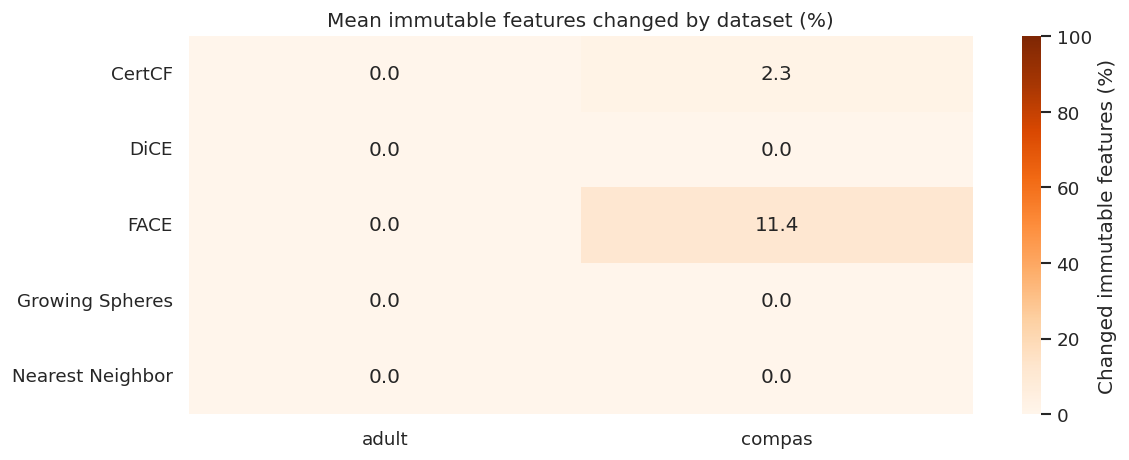

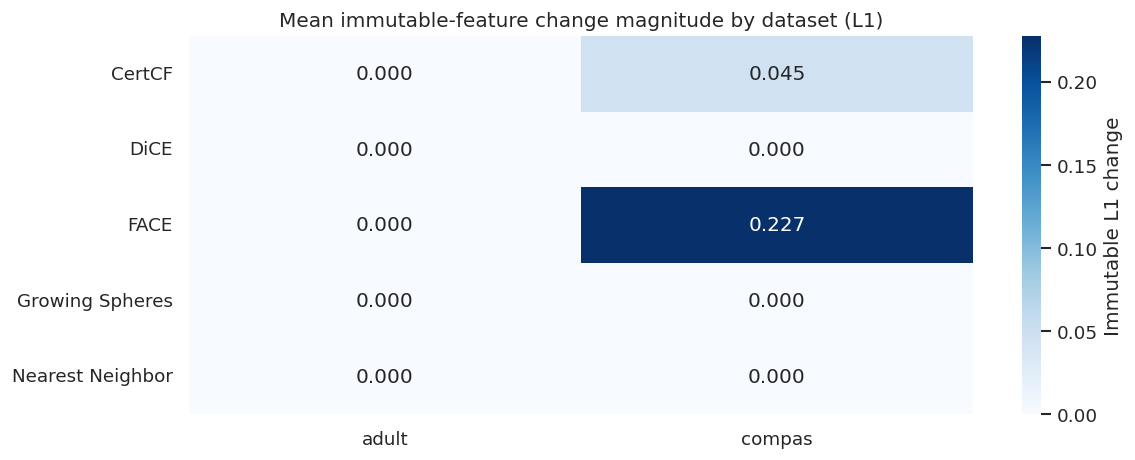

In [9]:
constraint_summary = constraint_quality_summary(df, order=order)
constraint_tables = constraint_quality_tables(df, order=order)

if constraint_summary.empty:
    print('No categorical OHE datasets are present in the current shared-success subset.')
else:
    categorical_datasets = list(constraint_tables['ohe_valid_pct'].columns)
    skipped_constraint_datasets = sorted(set(datasets_here) - set(categorical_datasets))
    if skipped_constraint_datasets:
        print('Skipping numerical-only datasets:', ', '.join(skipped_constraint_datasets))

    display(
        style_method_table(
            constraint_summary,
            fmt={
                'ohe_valid_pct': '{:.1f}%',
                'mean_invalid_block_pct': '{:.1f}%',
                'mean_ohe_snap_l1': '{:.3f}',
                'immutable_valid_pct': '{:.1f}%',
                'mean_immutable_change_pct': '{:.1f}%',
                'mean_immutable_l1': '{:.3f}',
            },
            maximize=['ohe_valid_pct', 'immutable_valid_pct'],
            minimize=['mean_invalid_block_pct', 'mean_ohe_snap_l1', 'mean_immutable_change_pct', 'mean_immutable_l1'],
        )
    )

    plot_heatmap(
        constraint_tables['ohe_valid_pct'],
        title='OHE-valid counterfactuals by dataset (%)',
        cmap='Greens',
        fmt='.1f',
        cbar_label='OHE-valid CFs (%)',
        vmin=0,
        vmax=100,
    )
    plt.show()

    plot_heatmap(
        constraint_tables['mean_invalid_block_pct'],
        title='Mean invalid OHE blocks by dataset (%)',
        cmap='Oranges',
        fmt='.1f',
        cbar_label='Invalid categorical blocks (%)',
        vmin=0,
        vmax=100,
    )
    plt.show()

    plot_heatmap(
        constraint_tables['mean_ohe_snap_l1'],
        title='Mean categorical snap distance by dataset (L1)',
        cmap='Blues',
        fmt='.3f',
        cbar_label='Snap L1 distance',
    )
    plt.show()

    if not constraint_tables['immutable_valid_pct'].empty:
        immutable_datasets = list(constraint_tables['immutable_valid_pct'].columns)
        print('Immutable-feature diagnostics available for:', ', '.join(immutable_datasets))
        plot_heatmap(
            constraint_tables['immutable_valid_pct'],
            title='Immutable-feature validity by dataset (%)',
            cmap='Greens',
            fmt='.1f',
            cbar_label='Immutable-valid CFs (%)',
            vmin=0,
            vmax=100,
        )
        plt.show()

        plot_heatmap(
            constraint_tables['mean_immutable_change_pct'],
            title='Mean immutable features changed by dataset (%)',
            cmap='Oranges',
            fmt='.1f',
            cbar_label='Changed immutable features (%)',
            vmin=0,
            vmax=100,
        )
        plt.show()

        plot_heatmap(
            constraint_tables['mean_immutable_l1'],
            title='Mean immutable-feature change magnitude by dataset (L1)',
            cmap='Blues',
            fmt='.3f',
            cbar_label='Immutable L1 change',
        )
        plt.show()


In [13]:
# successful rows only
df_success = df[df["success"]].copy()

# how many distinct methods exist?
n_methods = df["method"].nunique()

# query_idx solved by all methods
common_queries = (
    df_success.groupby("query_idx")["method"]
    .nunique()
    .loc[lambda x: x == n_methods]
    .index
)

# keep only those rows
df_fair = df[df["query_idx"].isin(common_queries)].copy()

In [20]:
df_fair

,method,query_idx,space,y_orig,y_cf,success,build_time_s,runtime_s,params,error,...,x_cf_97,x_cf_98,x_cf_99,x_cf_100,x_cf_101,x_cf_102,x_cf_103,dataset,method_label,source_class
0,nn,575,gen,0,1,True,3.954423,0.000046,"{""norm"": 1, ""subsample_method"": ""kmedoids"", ""k...",None,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,adult,Nearest Neighbor,0
1,nn,745,gen,0,1,True,3.954423,0.000044,"{""norm"": 1, ""subsample_method"": ""kmedoids"", ""k...",None,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,adult,Nearest Neighbor,0
2,nn,1023,gen,1,0,True,3.954423,0.000050,"{""norm"": 1, ""subsample_method"": ""kmedoids"", ""k...",None,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,adult,Nearest Neighbor,1
3,nn,1666,gen,1,0,True,3.954423,0.000047,"{""norm"": 1, ""subsample_method"": ""kmedoids"", ""k...",None,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,adult,Nearest Neighbor,1
4,nn,1810,gen,0,1,True,3.954423,0.000042,"{""norm"": 1, ""subsample_method"": ""kmedoids"", ""k...",None,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,adult,Nearest Neighbor,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,cpp,3406,raw,0,1,True,10.433671,0.015918,"{""checkpoint"": ""checkpoints/lending_club_class...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lending_club,CertCF,0
821,cpp,3438,raw,0,1,True,10.433671,2.163185,"{""checkpoint"": ""checkpoints/lending_club_class...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lending_club,CertCF,0
822,cpp,3545,raw,1,0,True,10.433671,0.016947,"{""checkpoint"": ""checkpoints/lending_club_class...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lending_club,CertCF,1
823,cpp,3721,raw,1,0,True,10.433671,0.036794,"{""checkpoint"": ""checkpoints/lending_club_class...",None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lending_club,CertCF,1
